## Testing Bias Mapping

### Avalaible data:
* Observations
* ERA5 (historical)
* CMIP (historical)
* CMIP (future)

### Possible bias correcting methods:
* method1
* method2
* method3

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ewatercycle.observation.grdc import get_grdc_data
import xarray as xr
import pandas as pd

import seaborn as sns

### Import Data

#### Observations

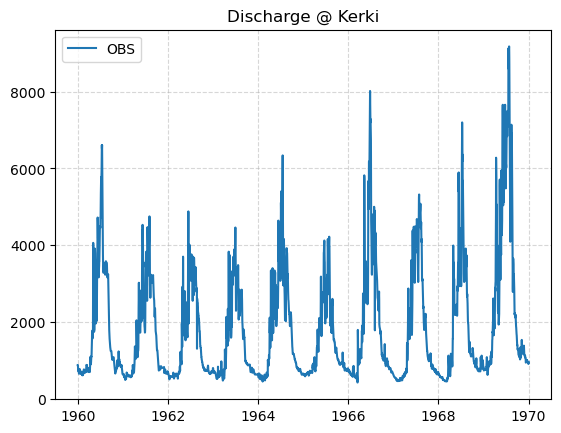

In [2]:
# Import Data

ds = get_grdc_data('2617110',
                   '1960-01-01T00:00Z',
                   '1970-01-01T00:00Z',
                   data_home = "../../data/GRDC/Daily")



obs = ds['streamflow'].to_pandas()
plt.plot(obs.index, obs.values, label = "OBS")
plt.title('Discharge @ Kerki')
plt.legend()
plt.grid(linestyle = '--', alpha = 0.5)
plt.show()

#### ERA5

In [3]:
file_era5 = "../../model_runs/HBV/ensemble_full/HBV_Kerki_ensemble_5020_m3s.nc"
sim_era5 = xr.open_dataset(file_era5)
sim_era5.close()

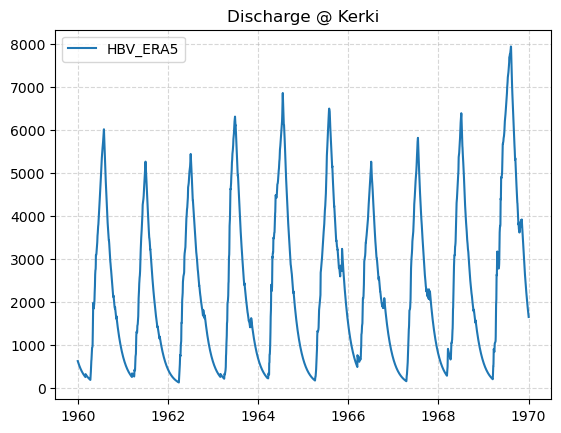

In [4]:
sim_era5_1= sim_era5.sel(particle = 1).sel(time= slice("1960-01-01","1970-01-01"))
sim_era5_1
plt.plot(sim_era5_1['time'], sim_era5_1['discharge'], label = 'HBV_ERA5')
plt.title('Discharge @ Kerki')
plt.legend()
plt.grid(linestyle = '--', alpha = 0.5)
plt.show()



#### CMIP Historical

In [5]:
file_cmip = "../../model_runs/HBV/CMIP_runs/HBV_Kerki_ensemble_CMIP_historical_m3s.nc"
sim_cmip = xr.open_dataset(file_cmip)
sim_cmip.close()

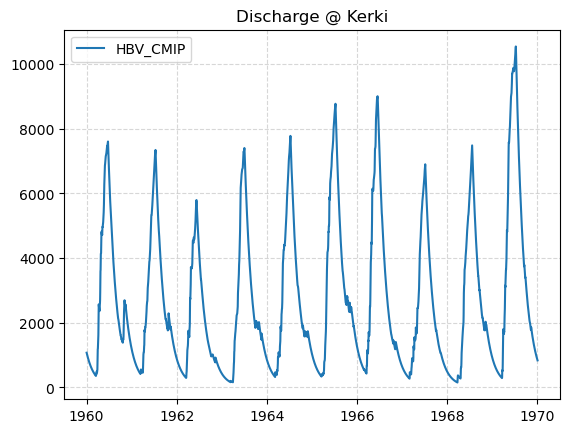

In [6]:
sim_cmip_1= sim_cmip.sel(particle = 1).sel(time= slice("1960-01-01","1970-01-01"))
sim_cmip_1
plt.plot(sim_cmip_1['time'], sim_cmip_1['discharge'], label = 'HBV_CMIP')
plt.title('Discharge @ Kerki')
plt.legend()
plt.grid(linestyle = '--', alpha = 0.5)
plt.show()



#### CMIP Future

In [29]:
file_cmip_future = "../../model_runs/HBV/CMIP_runs/HBV_Kerki_ensemble_CMIP_future_m3s.nc"
sim_cmip_f = xr.open_dataset(file_cmip_future)
sim_cmip_f.close()

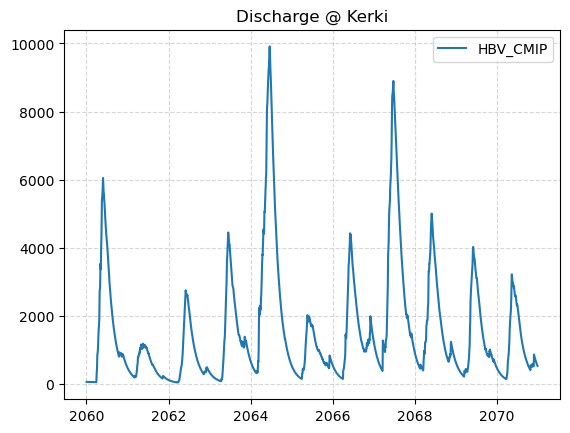

In [30]:
sim_cmip_f1= sim_cmip_f.sel(particle = 1)
sim_cmip_f1
plt.plot(sim_cmip_f1['time'], sim_cmip_f1['discharge'], label = 'HBV_CMIP')
plt.title('Discharge @ Kerki')
plt.legend()
plt.grid(linestyle = '--', alpha = 0.5)
plt.show()



In [32]:
sim_cmip_1['discharge'].to_pandas()
sim_era5_1['discharge'].to_pandas()
sim_cmip_f1['discharge'].to_pandas()

time
2060-01-02 12:00:00     67.465133
2060-01-03 12:00:00     67.377678
2060-01-04 12:00:00     67.290279
2060-01-05 12:00:00     67.202837
2060-01-06 12:00:00     67.115415
                          ...    
2070-12-27 12:00:00    568.263988
2070-12-28 12:00:00    559.754541
2070-12-29 12:00:00    551.380262
2070-12-30 12:00:00    543.138970
2070-12-31 12:00:00    535.028449
Name: discharge, Length: 4017, dtype: float64

### Combined plot

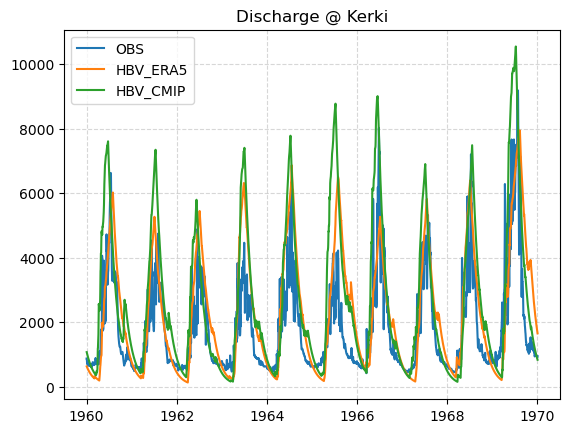

In [9]:
plt.plot(obs.index, obs.values, label = "OBS")
plt.plot(sim_era5_1['time'], sim_era5_1['discharge'], label = 'HBV_ERA5')
plt.plot(sim_cmip_1['time'], sim_cmip_1['discharge'], label = 'HBV_CMIP')
plt.title('Discharge @ Kerki')
plt.legend()
plt.grid(linestyle = '--', alpha = 0.5)
plt.show()



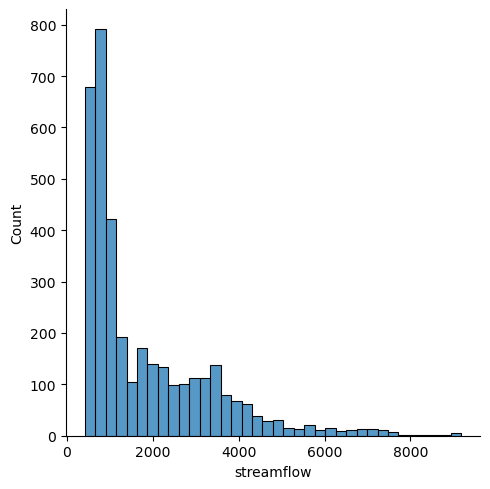

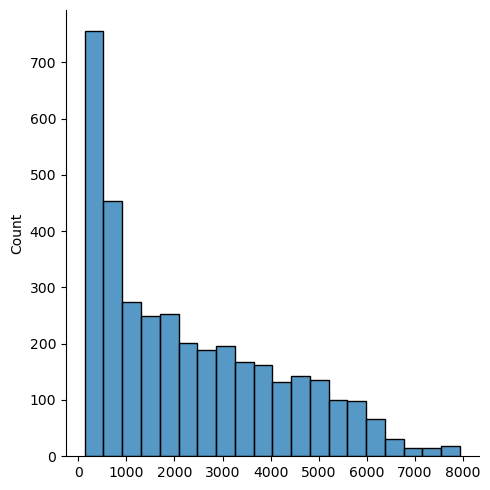

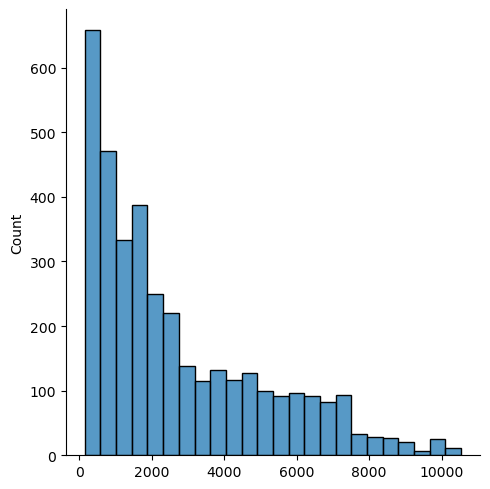

In [10]:
sns.displot(obs)
sns.displot(sim_era5_1['discharge'])
sns.displot(sim_cmip_1['discharge'])

In [11]:
sim_era5_1

<xarray.Dataset> Size: 58kB
Dimensions:    (time: 3654)
Coordinates:
  * time       (time) datetime64[ns] 29kB 1960-01-01T12:00:00 ... 1970-01-01T...
    particle   int64 8B 1
Data variables:
    discharge  (time) float64 29kB 629.1 619.8 610.6 ... 1.68e+03 1.654e+03

<Axes: xlabel='Discharge', ylabel='Count'>

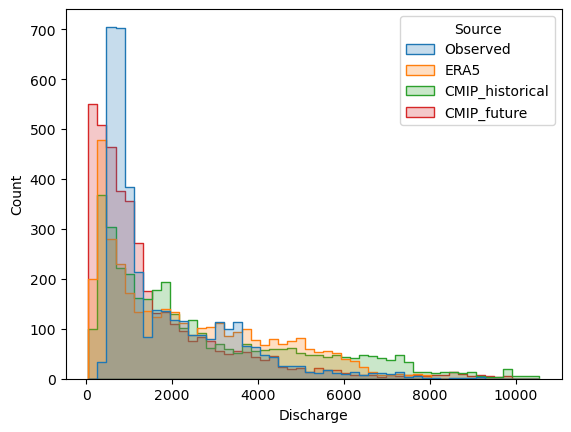

In [34]:
df = pd.concat([
    obs.rename("Observed"),
    sim_era5_1['discharge'].to_pandas().rename("ERA5"),
    sim_cmip_1['discharge'].to_pandas().rename("CMIP_historical"),
    sim_cmip_f1['discharge'].to_pandas().rename("CMIP_future")
], axis=1)

df_long = df.melt(var_name="Source", value_name="Discharge")


sns.histplot(
    data=df_long,
    x="Discharge",
    hue="Source",
    bins=50,
    element="step",
    common_norm=False
)

In [35]:
df = df.resample("1D").mean()
df.head()

,Observed,ERA5,CMIP_historical,CMIP_future
time,,,,
1960-01-01,875.0,629.127442,1072.037129,NaN
1960-01-02,875.0,619.790821,1055.757452,NaN
1960-01-03,798.0,610.601525,1039.736020,NaN
1960-01-04,770.0,601.557212,1023.968643,NaN
1960-01-05,722.0,592.655628,1008.451361,NaN


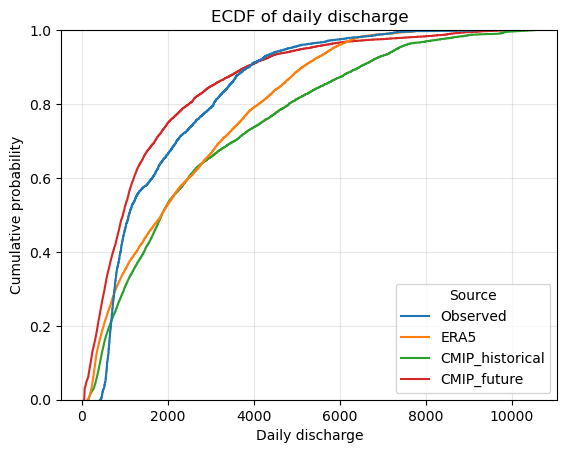

In [36]:
df_long = df.reset_index().melt(id_vars='time', var_name='Source', value_name='Discharge')

sns.ecdfplot(data=df_long, x='Discharge', hue='Source')
plt.xlabel("Daily discharge")
plt.ylabel("Cumulative probability")
plt.title("ECDF of daily discharge")
plt.grid(alpha=0.3)
plt.show()


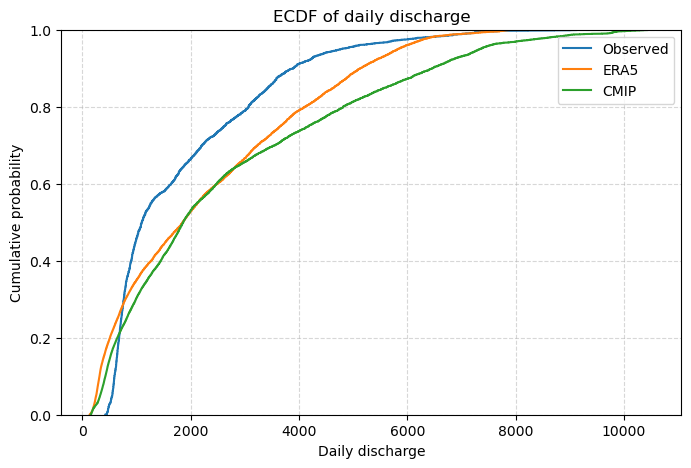

In [15]:


plt.figure(figsize=(8,5))

sns.ecdfplot(df['Observed'], label="Observed")
sns.ecdfplot(df['ERA5'], label="ERA5")
sns.ecdfplot(df['CMIP'], label="CMIP")

plt.xlabel("Daily discharge")
plt.ylabel("Cumulative probability")
plt.title("ECDF of daily discharge")
plt.legend()
plt.grid(linestyle = '--', alpha=0.5)
plt.show()

In [16]:
!pip install python-cmethods

Defaulting to user installation because normal site-packages is not writeable


In [17]:
from cmethods import adjust



In [18]:

df_d = df.dropna()
# convert daily aligned pandas to xarray DataArrays with explicit names
ds_obsh = xr.Dataset(
    data_vars={
        "discharge": ("time", df_d['Observed'].values)
    },
    coords={
        "time": df_d.index
    }
)

ds_simh = xr.Dataset(
    data_vars={
        "discharge": ("time", df_d['ERA5'].values)
    },
    coords={
        "time": df_d.index
    }
)

ds_simp = xr.Dataset(
    data_vars={
        "discharge": ("time", df_d['CMIP'].values)
    },
    coords={
        "time": df_d.index
    }
)


ds_simp

<xarray.Dataset> Size: 58kB
Dimensions:    (time: 3654)
Coordinates:
  * time       (time) datetime64[ns] 29kB 1960-01-01 1960-01-02 ... 1970-01-01
Data variables:
    discharge  (time) float64 29kB 1.072e+03 1.056e+03 1.04e+03 ... 848.4 835.6

In [19]:
qdm_adjusted = adjust(
    method="quantile_delta_mapping",
    obs=ds_obsh['discharge'],
    simh=ds_simh['discharge'],
    simp=ds_simp['discharge'],
    n_quantiles=250,
    kind="*"
)

In [20]:
qdm_adjusted

<xarray.Dataset> Size: 58kB
Dimensions:    (time: 3654)
Coordinates:
  * time       (time) datetime64[ns] 29kB 1960-01-01 1960-01-02 ... 1970-01-01
Data variables:
    discharge  (time) float64 29kB 944.9 942.6 939.1 936.4 ... 905.5 900.6 897.3
Attributes:
    cmethods_version:      2.3.2
    cmethods_method:       quantile_delta_mapping
    cmethods_timestamp:    2026-01-13 08:52:39 UTC
    cmethods_source:       https://github.com/btschwertfeger/python-cmethods
    cmethods_kind:         *
    cmethods_n_quantiles:  250

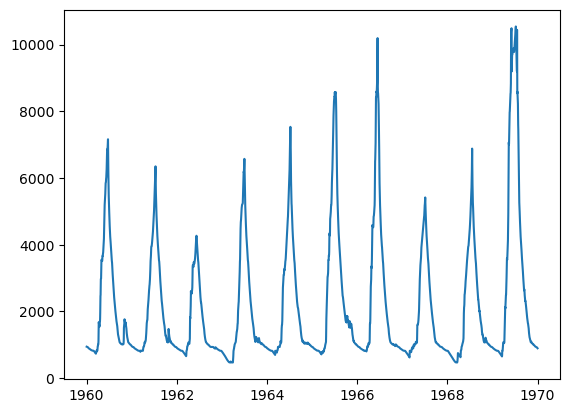

In [21]:
plt.plot(qdm_adjusted['time'], qdm_adjusted['discharge'],label='qdm_adjusted')

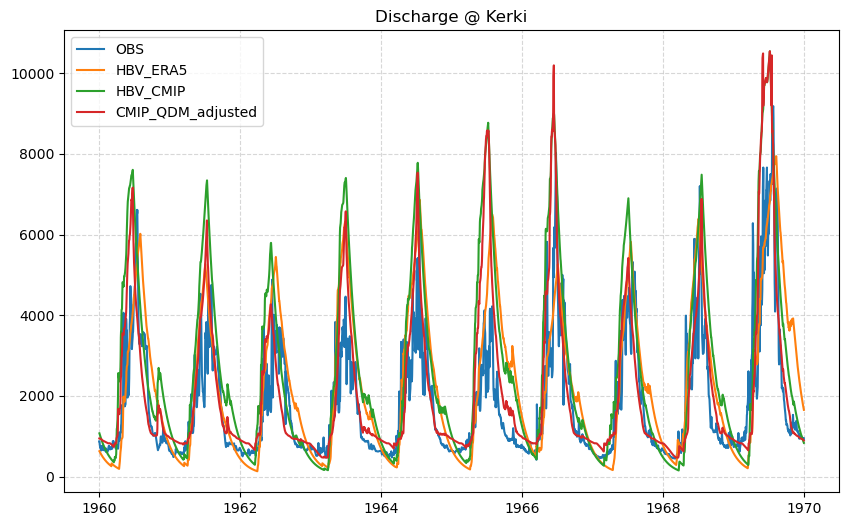

In [22]:
plt.figure(figsize=(10,6))  # width=10, height=6 inches
plt.plot(obs.index, obs.values, label = "OBS")
plt.plot(sim_era5_1['time'], sim_era5_1['discharge'], label = 'HBV_ERA5')
plt.plot(sim_cmip_1['time'], sim_cmip_1['discharge'], label = 'HBV_CMIP')
plt.plot(qdm_adjusted['time'], qdm_adjusted['discharge'],label='CMIP_QDM_adjusted')
plt.title('Discharge @ Kerki')
plt.legend()
plt.grid(linestyle = '--', alpha = 0.5)
plt.show()



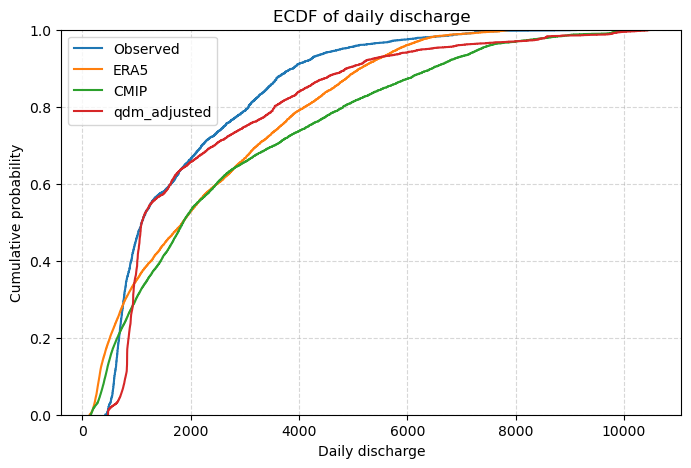

In [23]:

plt.figure(figsize=(8,5))

sns.ecdfplot(df['Observed'], label="Observed")
sns.ecdfplot(df['ERA5'], label="ERA5")
sns.ecdfplot(df['CMIP'], label="CMIP")
sns.ecdfplot(qdm_adjusted['discharge'], label="qdm_adjusted")


plt.xlabel("Daily discharge")
plt.ylabel("Cumulative probability")
plt.title("ECDF of daily discharge")
plt.legend()
plt.grid(linestyle = '--', alpha=0.5)
plt.show()

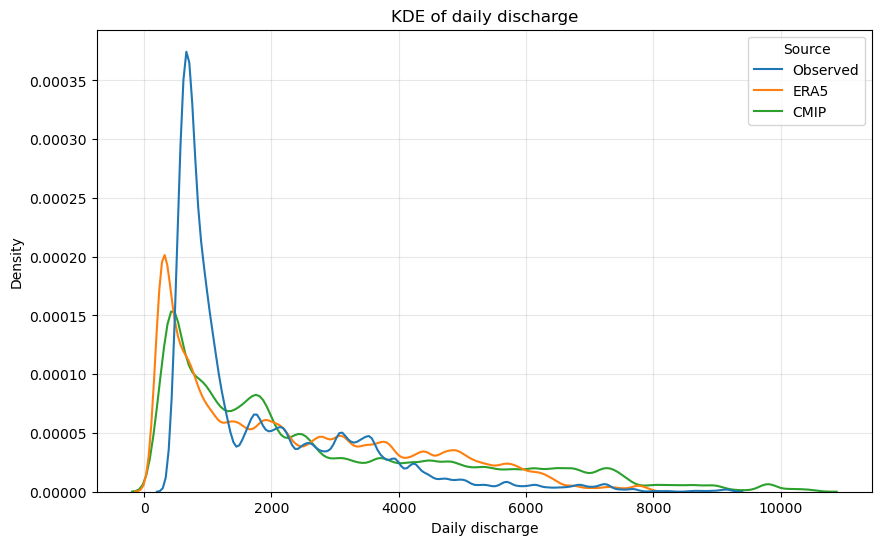

In [24]:
plt.figure(figsize=(10,6))
sns.kdeplot(data=df_long, x="Discharge", hue="Source", fill=False,bw_adjust=.25)
plt.xlabel("Daily discharge")
plt.ylabel("Density")
plt.title("KDE of daily discharge")
plt.grid(alpha=0.3)
plt.show()

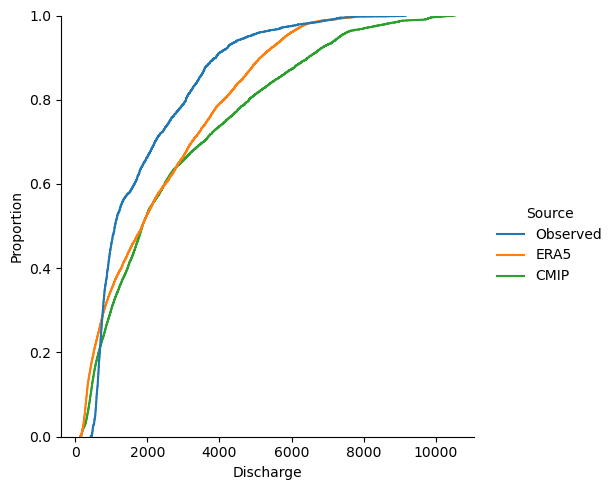

In [25]:
sns.displot(df_long, x="Discharge", hue="Source", kind="ecdf")

In [26]:
df_long

,time,Source,Discharge
0,1960-01-01,Observed,875.000000
1,1960-01-02,Observed,875.000000
2,1960-01-03,Observed,798.000000
3,1960-01-04,Observed,770.000000
4,1960-01-05,Observed,722.000000
...,...,...,...
10957,1969-12-28,CMIP,887.989678
10958,1969-12-29,CMIP,874.585330
10959,1969-12-30,CMIP,861.392837
10960,1969-12-31,CMIP,848.408877
